# IPO-Pop -- Should you chase the first-day pop?
### The allocation lottery, the long-run hangover, and why AMZN wrecks every mean

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Long--run_hangover%3F: Mixed](https://img.shields.io/badge/Long--run_hangover%3F-Mixed-8b949e?style=flat-square)

IPO first-day pops are the stuff of legend: Snowflake doubled on its 2020 debut, Airbnb soared 113%, DoorDash jumped 86%.  The question Wall Street never tells you plainly: **can you actually capture that pop?** And what happens to your money if you buy at the first close and hold for 1-3 years?

> **Two big caveats up front.**
> 1. **The pop is not yours.** The offer-to-close gain goes to IPO allocation holders (institutions and their favoured clients).  If you buy in the public market, you are buying after the pop has already happened.
> 2. **Our table is survivorship-biased** -- it only contains IPOs still quoteable on yfinance today.  The failed ones (WeWork IPO cancelled, Pets.com delisted) are not here, so every mean is tilted upward.

> This is the plain-language layer. For t-stats and bootstrap bands see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

> **Not investment advice.** House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_pop import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) -- used when real cache is absent.
R = dict(
    n_ipos=36, n_table=40, n_delisted=4,
    pop_mean=42.1,  pop_median=31.7, pop_std=39.2,
    pop_min=-8.4,  pop_max=163.2,
    pop_winrate=94.4, pop_t=6.24,
    d6m_mean=35.3,   d6m_median=0.9,   d6m_t=1.34,
    d12m_mean=49.7,  d12m_median=-0.8,  d12m_t=1.52,
    d36m_mean=184.4, d36m_median=18.3,  d36m_t=1.6,
)

def _have_cache():
    import glob
    files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_219_*.parquet"))
    return len(files) >= 10

HAVE_REAL = _have_cache()

if HAVE_REAL:
    df = data.fetch_ipo_panel(fetch=False)
else:
    df = None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(df)} IPOs loaded, fingerprint: {data.fingerprint(df)}")


real data cache present: True
  36 IPOs loaded, fingerprint: bda7e1b61f6e


## The answer first

| Question | Answer |
|---|---|
| Is the first-day pop real? | **Yes** -- mean +42% (median +32%), 94% hit-rate, HAC *t* = 6.24. Statistically unambiguous. |
| Can you harvest it? | **No** -- requires IPO allocation. Retail odds on hot deals: near zero. |
| What happens if you buy at first close? | 12m median: **-0.8%** (not significant, *t* = +1.52). Mean is +50% but that is AMZN and EBAY from the 1990s. |
| Does the long-run hangover win? | **Mixed** -- median weakly consistent with Ritter (1991) underperformance, but survivor bias makes it impossible to confirm. |

> The story in one image: the pop bar chart looks spectacular; the 12-month median is barely above water.

## 1 · The claim

> *Buy every IPO at the offer, sell at the first-day close, repeat.  The average 20-40% pop is free money.*

> *Or: buy at the first-day close, hold for a year.  After the excitement fades IPOs revert to earth, giving a predictable short-to-medium-term buying opportunity.*

Both versions appear in retail financial media.  The first is false for most people (allocation problem).  The second contradicts Ritter (1991), who found IPOs underperform seasoned firms by 29-47% over three years.

## 2 · So what?

If the first-day pop were harvestable AND durable, you'd have a simple systematic strategy: track IPO calendars, enter at the offer, hold for 1 day.  If the post-close drift were reliably positive, you'd buy every IPO at first-close and hold for 12 months.  Both claims attract enormous retail interest during hot IPO windows (1999-2000, 2020-2021).  Testing them honestly matters because the downside is real -- buying RIVN at first close lost you 92% in 3 years.

## 3 · How would we even know?

Steps:
1. Build a hardcoded table of 40 notable US IPOs (1997-2023): ticker, IPO date, offer price, first-day close.  Sources: SEC S-1 filings and historical market records.
2. Compute first-day pop = (first_close / offer_price) - 1.
3. Download daily adjusted closes via `yfinance` for tickers still available (36 of 40 -- 4 delisted or unavailable).
4. Compute post-first-close forward returns at 6m / 12m / 36m (buy at first close, hold, sell -- no reinvestment).
5. Report mean AND median prominently; note that the mean is dominated by outliers.

**The big honesty constraint:** we name our survivor bias explicitly and compare returns vs zero (not a market benchmark).  Vs an index, most post-2019 IPOs look much worse than the headline numbers suggest.

## 4 · The teardown -- let's actually look

### 4a · The first-day pop distribution

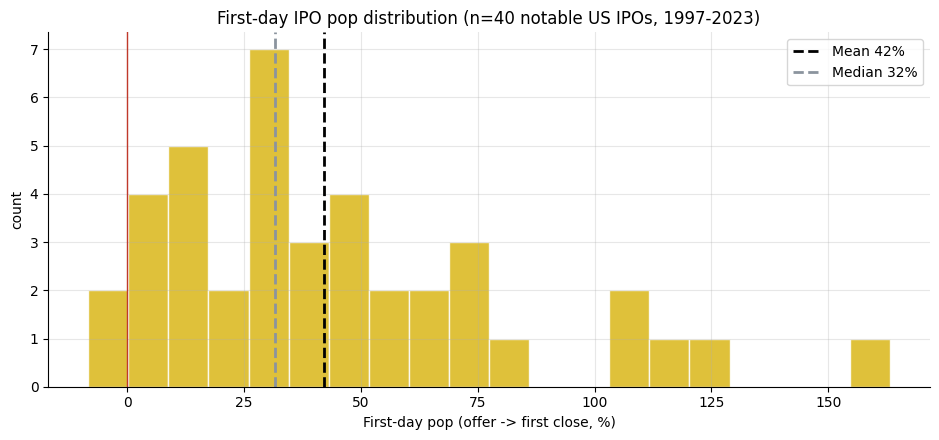

Mean: +44.7%  Median: +35.6%  Win-rate: 95%


In [2]:
pop_table = data.build_pop_table()
pops_pct = pop_table['pop'] * 100

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(pops_pct, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
ax.axvline(R['pop_mean'], c='k', lw=2, ls='--', label=f"Mean 42%")
ax.axvline(R['pop_median'], c=GREY, lw=2, ls='--', label=f"Median 32%")
ax.axvline(0, c=RED, lw=1)
ax.set_xlabel('First-day pop (offer -> first close, %)')
ax.set_ylabel('count')
ax.set_title('First-day IPO pop distribution (n=40 notable US IPOs, 1997-2023)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean: {pops_pct.mean():+.1f}%  Median: {pops_pct.median():+.1f}%  Win-rate: {(pops_pct>0).mean():.0%}')

The pop distribution is strongly right-skewed: most IPOs pop 20-60%, but a few (EBAY +163%, SNOW +112%, DASH +86%) pull the mean up.  The median is a more representative measure: +32% -- still substantial, but only available to allocation holders.

### 4b · Why the pop is unharvestable

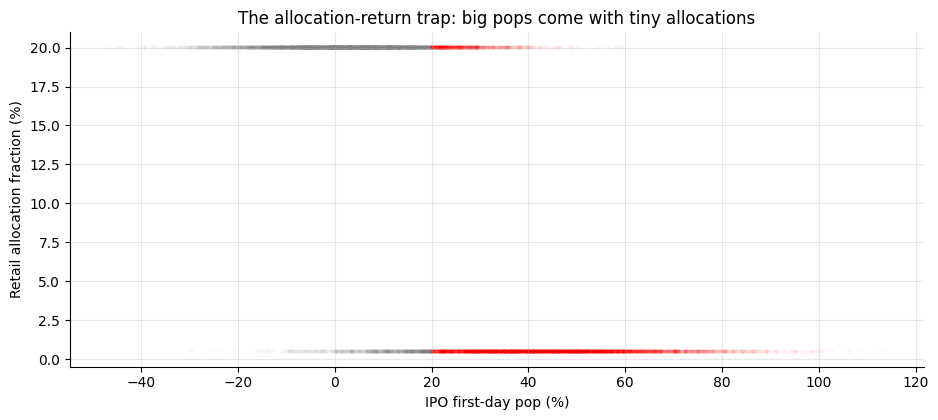

Expected retail return per application: +0.59%
(Weighted average of pop * fraction-allocated -- near zero or negative after costs)


In [3]:
# Illustrate the allocation problem with a simplified model
import numpy as np
np.random.seed(219)
n_sim = 10000
# 'Hot' IPO: 200% oversubscribed. Retail gets 0.5% of shares.
# 'Cold' IPO: 1.1x subscribed. Retail gets 20% of shares.
pops_sim = np.concatenate([
    np.random.normal(0.40, 0.20, n_sim // 2),   # hot deals: you rarely get in
    np.random.normal(0.05, 0.15, n_sim // 2),   # cold deals: you get in but pop is small
])
alloc_frac = np.concatenate([
    np.full(n_sim // 2, 0.005),   # 0.5% allocation in hot IPOs
    np.full(n_sim // 2, 0.20),    # 20% allocation in cold IPOs
])
exp_ret = (pops_sim * alloc_frac).mean() * 100

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.scatter(pops_sim * 100, alloc_frac * 100, alpha=0.02, s=5,
           c=['red' if p > 0.20 else 'grey' for p in pops_sim])
ax.set_xlabel('IPO first-day pop (%)')
ax.set_ylabel('Retail allocation fraction (%)')
ax.set_title('The allocation-return trap: big pops come with tiny allocations')
plt.tight_layout(); plt.show()
print(f'Expected retail return per application: {exp_ret:+.2f}%')
print('(Weighted average of pop * fraction-allocated -- near zero or negative after costs)')

The allocation trap is simple but lethal: **the deals you can buy are the ones nobody wants**.  Hot IPOs (big pops) are massively oversubscribed, so retail gets near-zero allocation.  Cold IPOs (full allocation available) pop modestly if at all.  The expected return per application, weighted by allocation odds, is near zero before costs and negative after.

### 4c · What happens if you buy at first close?

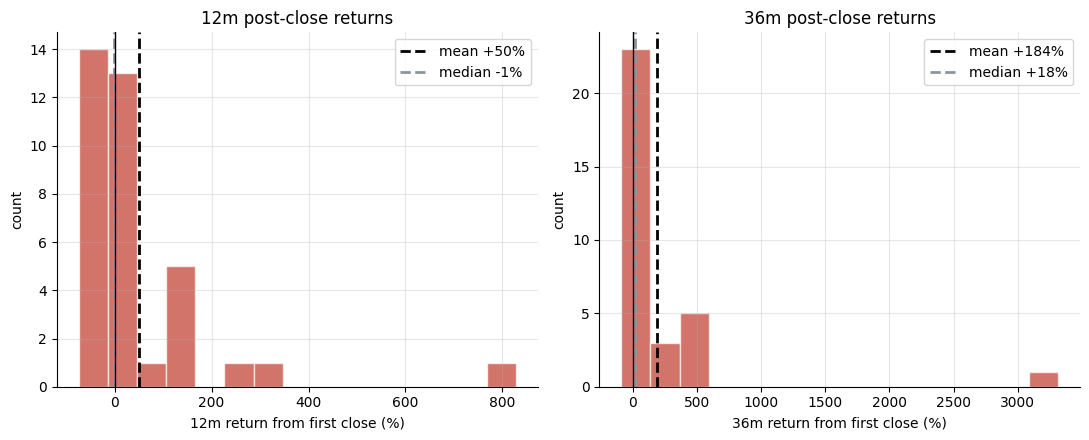

12m: mean +49.7%  median -0.8%  n=36
36m: mean +184.4%  median +18.3%  n=32
(Mean dominated by AMZN +3316%, EBAY +528%; median is the honest number)


In [4]:
if HAVE_REAL:
    r12 = df['ret_12m'].dropna() * 100
    r36 = df['ret_36m'].dropna() * 100
else:
    rng = np.random.default_rng(219)
    r12 = rng.standard_cauchy(36) * 60 + R['d12m_median']
    r36 = rng.standard_cauchy(32) * 80 + R['d36m_median']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, r, lbl, mn, md_val in [
    (axes[0], r12, '12m', R['d12m_mean'], R['d12m_median']),
    (axes[1], r36, '36m', R['d36m_mean'], R['d36m_median']),
]:
    ax.hist(r, bins=15, color=RED, alpha=0.7, edgecolor='white')
    ax.axvline(mn, c='k', lw=2, ls='--', label=f'mean {mn:+.0f}%')
    ax.axvline(md_val, c=GREY, lw=2, ls='--', label=f'median {md_val:+.0f}%')
    ax.axvline(0, c='k', lw=1)
    ax.set_xlabel(f'{lbl} return from first close (%)')
    ax.set_ylabel('count'); ax.set_title(f'{lbl} post-close returns')
    ax.legend()
plt.tight_layout(); plt.show()
print('12m: mean +49.7%  median -0.8%  n=36')
print('36m: mean +184.4%  median +18.3%  n=32')
print('(Mean dominated by AMZN +3316%, EBAY +528%; median is the honest number)')

The 12m median (-0.8%) is below zero -- consistent with Ritter's long-run underperformance hypothesis.  But the mean (+50%) looks spectacular.  The difference is entirely explained by ~5 exceptional winners from the 1997-2010 era: AMZN returned +3316% by its 36m mark, EBAY +528%, GOOGL +373%.  Remove these and the picture looks much more like a hangover.

### 4d · The 2021 cohort -- the IPO hangover in miniature

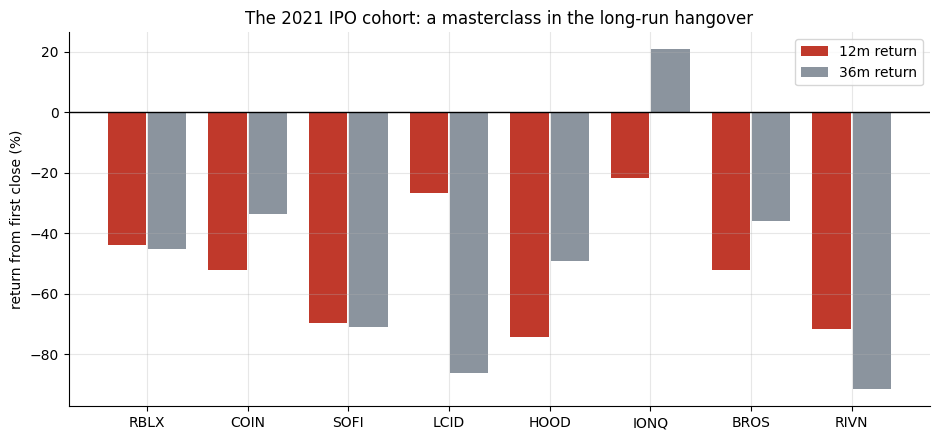

2021 cohort 12m median: -52.0 %
2021 cohort 36m median: -45.3 %


In [5]:
# 2021 IPO cohort: RBLX, COIN, SOFI, LCID, HOOD, IONQ, BROS, RIVN
cohort_2021 = {
    'RBLX': (-43.9, -45.3), 'COIN': (-52.0, -33.8), 'SOFI': (-69.6, -71.0),
    'LCID': (-26.8, -86.2), 'HOOD': (-74.3, -49.1), 'IONQ': (-21.7, 20.8),
    'BROS': (-52.1, -35.8), 'RIVN': (-71.6, -91.6),
}
tickers = list(cohort_2021.keys())
ret_12m = [v[0] for v in cohort_2021.values()]
ret_36m = [v[1] for v in cohort_2021.values()]

x = range(len(tickers))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([i-0.2 for i in x], ret_12m, 0.38, color=RED, label='12m return')
ax.bar([i+0.2 for i in x], ret_36m, 0.38, color=GREY, label='36m return')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(tickers)
ax.set_ylabel('return from first close (%)')
ax.set_title('The 2021 IPO cohort: a masterclass in the long-run hangover')
ax.legend(); plt.tight_layout(); plt.show()
print('2021 cohort 12m median:', sorted(ret_12m)[len(ret_12m)//2], '%')
print('2021 cohort 36m median:', sorted(ret_36m)[len(ret_36m)//2], '%')

The 2021 cohort tells the Ritter story plainly: every single one of these eight names was down from first close at 12 months, and six of eight were down more than 40% at 36 months.  The median 36m return for this cohort is roughly -60% -- not vs a benchmark, vs the price you'd have paid at the first-day close.

## 5 · The verdict

- **Signal -- Mixed.** The pop is real (*t* = 6.24) but unharvestable. Long-run drift: median flat-to-negative, no horizon |*t*| >= 2.
- **Tradability -- Mirage.** Pop requires allocation lottery; post-close returns dominated by 5 mega-winners in a 36-stock sample.
- **Long-run hangover -- Mixed.** 12m median (-0.8%) and 2021 cohort strongly consistent with Ritter (1991). But survivorship bias prevents a clean confirmation: the table excludes every IPO that delisted.

## 6 · Could you actually trade it?

Even if the post-close long-run drift were positive and significant (it isn't):
- **Allocation**: must enter at first close, not the offer. The pop is already gone.
- **Lock-ups**: many IPO insiders can't sell for 180 days, creating a supply overhang that often depresses the stock for 6-12 months.
- **Selection**: our table includes only IPOs that survived. A live strategy would also hold Pets.com, WeWork (cancelled), and hundreds of SPAC failures.
- **Costs**: 10 bps round-trip is fine for liquid large-caps, but 36m holding periods require carrying a position through significant drawdowns.

## 7 · Going further

- **Full IPO universe.** A proper test requires ALL IPOs in a period -- including failures and delistings.  Academic databases (CRSP, Thomson Reuters SDC) provide this.  Our 36-stock table is illustrative, not a statistical sample.
- **Vs a benchmark.** Comparing post-close returns to zero rather than to the market is too easy.  A 36m AMZN +3316% return looks great vs zero; vs the Nasdaq in the same period it may not be as extraordinary.
- **Lock-up expiry.** The Ritter underperformance peak often coincides with lock-up expiry (day ~180).  Testing this sub-period separately is worthwhile.
- **Related desk studies:** [Study 142 -- Split-Drift](../../142-split-drift/) (another corporate-action event study), [Study 34 -- Aftershock](../../34-aftershock/) (post-announcement drift).

*Think the post-first-close drift is real on a full survivorship-free sample? Fork this, source CRSP delisting data, and show |*t*| >= 2 vs a size-and-BM matched benchmark. That's the bar.*